# Projeto Big Data — Crimes em Chicago
**Pipeline:** Ingestão → ETL → EDA → Machine Learning com Apache Spark  
**Target:** `Arrest` (Classificação Binária — predizer se o crime resultará em prisão)

---
## Parte 1 — Ambiente e Ingestão (CSV → Parquet)

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, to_timestamp, hour, dayofweek, month
from pyspark.sql.types import IntegerType, DoubleType
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import (
    LogisticRegression,
    DecisionTreeClassifier,
    MultilayerPerceptronClassifier
)
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

In [2]:
# Conecta ao cluster Spark (Master + 2 Workers via Docker)
spark = SparkSession.builder \
    .appName("CrimesChicago_BigData") \
    .master("spark://spark-master:7077") \
    .config("spark.driver.host", "jupyter") \
    .config("spark.driver.bindAddress", "0.0.0.0") \
    .config("spark.driver.memory", "2g") \
    .config("spark.executor.memory", "2g") \
    .config("spark.sql.shuffle.partitions", "50") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print(f"Spark version: {spark.version}")
print(f"Master: {spark.sparkContext.master}")

Spark version: 3.5.0
Master: spark://spark-master:7077


### 1.1 Leitura dos CSVs do Data Lake Local

In [3]:
# Lê todos os CSVs da pasta /archive (suporta arquivo único ou particionado)
df_raw = spark.read.csv(
    "/home/jovyan/work/archive/",
    header=True,
    inferSchema=True
)

print(f"Total de linhas: {df_raw.count():,}")
print(f"Total de colunas: {len(df_raw.columns)}")
df_raw.printSchema()

Total de linhas: 7,941,286
Total de colunas: 23
root
 |-- _c0: integer (nullable = true)
 |-- ID: integer (nullable = true)
 |-- Case Number: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- Block: string (nullable = true)
 |-- IUCR: string (nullable = true)
 |-- Primary Type: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Location Description: string (nullable = true)
 |-- Arrest: string (nullable = true)
 |-- Domestic: string (nullable = true)
 |-- Beat: string (nullable = true)
 |-- District: string (nullable = true)
 |-- Ward: string (nullable = true)
 |-- Community Area: string (nullable = true)
 |-- FBI Code: string (nullable = true)
 |-- X Coordinate: string (nullable = true)
 |-- Y Coordinate: string (nullable = true)
 |-- Year: string (nullable = true)
 |-- Updated On: string (nullable = true)
 |-- Latitude: string (nullable = true)
 |-- Longitude: string (nullable = true)
 |-- Location: string (nullable = true)



In [4]:
df_raw.show(5)

+----+----+-----------+--------------------+-------------------+----+------------+-------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+--------------------+------------+-------------+--------------------+
| _c0|  ID|Case Number|                Date|              Block|IUCR|Primary Type|        Description|Location Description|Arrest|Domestic|Beat|District|Ward|Community Area|FBI Code|X Coordinate|Y Coordinate|Year|          Updated On|    Latitude|    Longitude|            Location|
+----+----+-----------+--------------------+-------------------+----+------------+-------------------+--------------------+------+--------+----+--------+----+--------------+--------+------------+------------+----+--------------------+------------+-------------+--------------------+
| 388|4785|   HP610824|10/07/2008 12:39:...|    000XX E 75TH ST|0110|    HOMICIDE|FIRST DEGREE MURDER|               ALLEY|  True|   False| 323|     3.

### 1.2 Conversão para Parquet (Otimização de Storage)
Parquet é colunar e binário — reduz I/O significativamente em comparação ao CSV para workloads analíticos.

In [5]:
PARQUET_PATH = "/home/jovyan/work/data_parquet/crimes_raw"

df_raw.write.mode("overwrite").parquet(PARQUET_PATH)
print(f"Parquet salvo em: {PARQUET_PATH}")

Parquet salvo em: /home/jovyan/work/data_parquet/crimes_raw


---
## Parte 2 — EDA e Pré-processamento (ETL)

### 2.1 Leitura Otimizada a partir do Parquet

In [6]:
df = spark.read.parquet(PARQUET_PATH)
df.printSchema()

root
 |-- _c0: integer (nullable = true)
 |-- ID: integer (nullable = true)
 |-- Case Number: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- Block: string (nullable = true)
 |-- IUCR: string (nullable = true)
 |-- Primary Type: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Location Description: string (nullable = true)
 |-- Arrest: string (nullable = true)
 |-- Domestic: string (nullable = true)
 |-- Beat: string (nullable = true)
 |-- District: string (nullable = true)
 |-- Ward: string (nullable = true)
 |-- Community Area: string (nullable = true)
 |-- FBI Code: string (nullable = true)
 |-- X Coordinate: string (nullable = true)
 |-- Y Coordinate: string (nullable = true)
 |-- Year: string (nullable = true)
 |-- Updated On: string (nullable = true)
 |-- Latitude: string (nullable = true)
 |-- Longitude: string (nullable = true)
 |-- Location: string (nullable = true)



### 2.2 Limpeza dos Dados

In [7]:
# Remove linhas com nulos nas colunas críticas
df = df.dropna(subset=["Date", "Primary Type", "Location Description",
                        "Arrest", "Latitude", "Longitude", "District", "Beat"])

# Remove registros com coordenadas inválidas (0,0)
df = df.filter((col("Latitude") != 0.0) & (col("Longitude") != 0.0))

print(f"Linhas após limpeza: {df.count():,}")

Linhas após limpeza: 7,834,133


### 2.3 Feature Engineering
Extrai `Hour`, `DayOfWeek` e `Month` do timestamp do crime para aumentar o poder preditivo.

In [8]:
# Parse do timestamp (formato Chicago: "MM/dd/yyyy hh:mm:ss a")
df = df.withColumn("Date_ts", to_timestamp(col("Date"), "MM/dd/yyyy hh:mm:ss a"))

# Features temporais derivadas
df = df.withColumn("Hour",      hour("Date_ts"))
df = df.withColumn("DayOfWeek", dayofweek("Date_ts"))
df = df.withColumn("Month",     month("Date_ts"))

# Variável alvo: Arrest como inteiro (0/1) — coluna é string "True"/"False", não booleana
df = df.withColumn("Arrest_label", (col("Arrest") == "True").cast(IntegerType()))

# Domestic como inteiro
df = df.withColumn("Domestic_int", (col("Domestic") == "True").cast(IntegerType()))

# Tipos numéricos para colunas de área/setor
df = df.withColumn("District",       col("District").cast(IntegerType()))
df = df.withColumn("Beat",           col("Beat").cast(IntegerType()))
df = df.withColumn("Community Area", col("Community Area").cast(IntegerType()))

# Latitude e Longitude precisam ser numéricas para o VectorAssembler
df = df.withColumn("Latitude",  col("Latitude").cast(DoubleType()))
df = df.withColumn("Longitude", col("Longitude").cast(DoubleType()))

In [9]:
# Seleciona apenas as colunas relevantes para o modelo
FEATURE_COLS = [
    "Primary Type", "Location Description",
    "Hour", "DayOfWeek", "Month",
    "District", "Beat", "Community Area",
    "Domestic_int", "Latitude", "Longitude"
]
TARGET_COL = "Arrest_label"

df = df.select(FEATURE_COLS + [TARGET_COL]).dropna()
print(f"Dataset final: {df.count():,} linhas | {len(df.columns)} colunas")
df.show(5)

Dataset final: 7,145,306 linhas | 12 colunas
+------------+--------------------+----+---------+-----+--------+----+--------------+------------+------------+-------------+------------+
|Primary Type|Location Description|Hour|DayOfWeek|Month|District|Beat|Community Area|Domestic_int|    Latitude|    Longitude|Arrest_label|
+------------+--------------------+----+---------+-----+--------+----+--------------+------------+------------+-------------+------------+
|    HOMICIDE|               ALLEY|  12|        3|   10|       3| 323|            69|           0|41.758275857|-87.622451031|           1|
|    HOMICIDE|              STREET|   3|        5|   10|      15|1533|            25|           0| 41.87025207|-87.746069362|           1|
|    HOMICIDE|       PARK PROPERTY|   8|        5|   10|       8| 831|            66|           0|41.770990476|-87.698901469|           0|
|    HOMICIDE|          RESTAURANT|   2|        6|   10|      15|1524|            25|           0|41.894916924|-87.757358

### 2.4 Análise Exploratória com Spark SQL

In [10]:
df.createOrReplaceTempView("crimes")

In [11]:
# Query 1: Top 10 tipos de crime por volume e taxa de prisão
spark.sql("""
    SELECT `Primary Type`,
           COUNT(*)                                          AS total_crimes,
           SUM(Arrest_label)                                 AS total_arrests,
           ROUND(SUM(Arrest_label) / COUNT(*) * 100, 2)     AS arrest_rate_pct
    FROM crimes
    GROUP BY `Primary Type`
    ORDER BY total_crimes DESC
    LIMIT 10
""").show(truncate=False)

+-------------------+------------+-------------+---------------+
|Primary Type       |total_crimes|total_arrests|arrest_rate_pct|
+-------------------+------------+-------------+---------------+
|THEFT              |1476390     |172606       |11.69          |
|BATTERY            |1298245     |298521       |22.99          |
|CRIMINAL DAMAGE    |835316      |58415        |6.99           |
|NARCOTICS          |796054      |789728       |99.21          |
|OTHER OFFENSE      |440885      |74728        |16.95          |
|ASSAULT            |432905      |102917       |23.77          |
|BURGLARY           |430571      |24545        |5.7            |
|MOTOR VEHICLE THEFT|328768      |28035        |8.53           |
|ROBBERY            |271450      |26855        |9.89           |
|DECEPTIVE PRACTICE |247715      |45350        |18.31          |
+-------------------+------------+-------------+---------------+



In [12]:
# Query 2: Distribuição de crimes e taxa de prisão por hora do dia
spark.sql("""
    SELECT Hour,
           COUNT(*)                             AS total_crimes,
           ROUND(AVG(Arrest_label) * 100, 2)   AS arrest_rate_pct
    FROM crimes
    GROUP BY Hour
    ORDER BY Hour
""").show(24)

+----+------------+---------------+
|Hour|total_crimes|arrest_rate_pct|
+----+------------+---------------+
|   0|      403228|          20.72|
|   1|      229719|          27.61|
|   2|      192507|          26.24|
|   3|      154958|          24.47|
|   4|      115499|          22.34|
|   5|       94796|          18.53|
|   6|      112191|          19.65|
|   7|      162555|          18.18|
|   8|      240473|          18.91|
|   9|      303084|          19.17|
|  10|      297721|           27.0|
|  11|      314678|          34.11|
|  12|      400676|          28.17|
|  13|      338553|          32.16|
|  14|      360388|           29.6|
|  15|      378631|           27.4|
|  16|      355230|          27.59|
|  17|      360625|          25.94|
|  18|      387114|          28.01|
|  19|      406217|          34.59|
|  20|      408911|          35.24|
|  21|      403222|          35.11|
|  22|      397418|          32.91|
|  23|      326912|          32.79|
+----+------------+---------

In [13]:
# Query 3: Distritos com maior volume de crimes e menor taxa de prisão (hotspots críticos)
spark.sql("""
    SELECT District,
           COUNT(*)                                         AS total_crimes,
           ROUND(SUM(Arrest_label) / COUNT(*) * 100, 2)   AS arrest_rate_pct
    FROM crimes
    WHERE District IS NOT NULL
    GROUP BY District
    HAVING COUNT(*) > 1000
    ORDER BY arrest_rate_pct ASC
    LIMIT 10
""").show()

+--------+------------+---------------+
|District|total_crimes|arrest_rate_pct|
+--------+------------+---------------+
|      16|      236834|          19.22|
|      14|      278375|          22.07|
|      19|      314362|          22.19|
|      22|      237994|          22.28|
|      17|      207422|          23.18|
|       4|      412844|           24.0|
|      20|      121718|          24.46|
|      24|      213411|          24.62|
|       8|      499754|          24.77|
|      18|      300508|          25.11|
+--------+------------+---------------+



### 2.5 Análise de Desbalanceamento da Classe `Arrest`

In [14]:
print("Distribuição da classe Arrest:")
df.groupBy(TARGET_COL).count().orderBy(TARGET_COL).show()

count_arrest    = df.filter(col(TARGET_COL) == 1).count()
count_no_arrest = df.filter(col(TARGET_COL) == 0).count()
total           = count_arrest + count_no_arrest

print(f"Arrests (1):    {count_arrest:,}  ({count_arrest/total*100:.1f}%)")
print(f"No Arrest (0):  {count_no_arrest:,}  ({count_no_arrest/total*100:.1f}%)")
print(f"Razão de desbalanceamento: 1:{count_no_arrest//count_arrest}")

Distribuição da classe Arrest:
+------------+-------+
|Arrest_label|  count|
+------------+-------+
|           0|5127304|
|           1|2018002|
+------------+-------+

Arrests (1):    2,018,002  (28.2%)
No Arrest (0):  5,127,304  (71.8%)
Razão de desbalanceamento: 1:2


### 2.6 Balanceamento — Undersampling da Classe Majoritária
Reduz a classe `Arrest=0` para equilibrar com `Arrest=1`, evitando viés nos modelos.

In [15]:
# Fração de amostragem para igualar as classes
fraction = count_arrest / count_no_arrest

df_majority = df.filter(col(TARGET_COL) == 0).sample(fraction=fraction, seed=42)
df_minority = df.filter(col(TARGET_COL) == 1)

df_balanced = df_majority.union(df_minority)

print(f"Dataset balanceado: {df_balanced.count():,} linhas")
df_balanced.groupBy(TARGET_COL).count().orderBy(TARGET_COL).show()

Dataset balanceado: 4,037,330 linhas
+------------+-------+
|Arrest_label|  count|
+------------+-------+
|           0|2019328|
|           1|2018002|
+------------+-------+



In [16]:
# Checkpoint: salva df_balanced antes da seção de ML
# Se o Spark cair durante o treino, não precisa reprocessar tudo do zero
BALANCED_PATH = "/home/jovyan/work/data_parquet/crimes_balanced"
df_balanced.write.mode("overwrite").parquet(BALANCED_PATH)
print(f"Checkpoint salvo em: {BALANCED_PATH}")

Checkpoint salvo em: /home/jovyan/work/data_parquet/crimes_balanced


---
## Parte 3 — Machine Learning (Pipeline + Avaliação)
> Padrão baseado em `aula_06_parte_2.ipynb`: Pipeline com StringIndexer → OneHotEncoder → VectorAssembler → Modelo

### 3.1 Configuração dos Estágios de Feature Engineering

In [17]:
# Colunas categóricas que precisam de encoding
CAT_COLS     = ["Primary Type", "Location Description"]
INDEXED_COLS = [c + "_idx" for c in CAT_COLS]
ENCODED_COLS = [c + "_enc" for c in CAT_COLS]

# Colunas numéricas prontas para uso
NUMERIC_COLS = [
    "Hour", "DayOfWeek", "Month",
    "District", "Beat", "Community Area",
    "Domestic_int", "Latitude", "Longitude"
]

# StringIndexer: transforma string em índice numérico
indexers = [
    StringIndexer(inputCol=c, outputCol=idx, handleInvalid="skip")
    for c, idx in zip(CAT_COLS, INDEXED_COLS)
]

# OneHotEncoder: transforma índice em vetor binário esparso
encoder = OneHotEncoder(
    inputCols=INDEXED_COLS,
    outputCols=ENCODED_COLS
)

# VectorAssembler: concatena todas as features em um único vetor
assembler = VectorAssembler(
    inputCols=ENCODED_COLS + NUMERIC_COLS,
    outputCol="features"
)

# Estágios base compartilhados por todos os modelos
BASE_STAGES = indexers + [encoder, assembler]

### 3.2 Divisão Treino / Teste e Cálculo do Tamanho do Vetor de Features

In [18]:
train_data, test_data = df_balanced.randomSplit([0.8, 0.2], seed=42)
print(f"Treino: {train_data.count():,} | Teste: {test_data.count():,}")

# Descobre o tamanho do vetor de features (necessário para configurar o MLP)
pre_pipeline  = Pipeline(stages=BASE_STAGES)
pre_model     = pre_pipeline.fit(train_data)
sample_vector = pre_model.transform(train_data.limit(1))
INPUT_SIZE    = len(sample_vector.select("features").first()[0])

print(f"Tamanho do vetor de features: {INPUT_SIZE}")

Treino: 3,230,261 | Teste: 807,069
Tamanho do vetor de features: 206


### 3.3 Função Auxiliar de Avaliação

In [19]:
def evaluate_model(predictions, label_col=TARGET_COL):
    """Extrai Accuracy, Precision, Recall e F1-Score via MulticlassClassificationEvaluator."""
    evaluator = MulticlassClassificationEvaluator(labelCol=label_col)
    metrics = {}
    for metric in ["accuracy", "weightedPrecision", "weightedRecall", "f1"]:
        evaluator.setMetricName(metric)
        metrics[metric] = round(evaluator.evaluate(predictions), 4)
    return metrics

### 3.4 Modelo 1 — Logistic Regression (Baseline)

In [20]:
lr = LogisticRegression(
    labelCol=TARGET_COL,
    featuresCol="features",
    maxIter=10
)

pipeline_lr = Pipeline(stages=BASE_STAGES + [lr])
model_lr    = pipeline_lr.fit(train_data)
pred_lr     = model_lr.transform(test_data)

metrics_lr = evaluate_model(pred_lr)
print("=== Logistic Regression ===")
for k, v in metrics_lr.items():
    print(f"  {k}: {v}")

=== Logistic Regression ===
  accuracy: 0.7992
  weightedPrecision: 0.8192
  weightedRecall: 0.7992
  f1: 0.7959


### 3.5 Modelo 2 — Decision Tree Classifier

In [21]:
dt = DecisionTreeClassifier(
    labelCol=TARGET_COL,
    featuresCol="features",
    maxDepth=5
)

pipeline_dt = Pipeline(stages=BASE_STAGES + [dt])
model_dt    = pipeline_dt.fit(train_data)
pred_dt     = model_dt.transform(test_data)

metrics_dt = evaluate_model(pred_dt)
print("=== Decision Tree Classifier ===")
for k, v in metrics_dt.items():
    print(f"  {k}: {v}")

=== Decision Tree Classifier ===
  accuracy: 0.7677
  weightedPrecision: 0.8253
  weightedRecall: 0.7677
  f1: 0.7568


### 3.6 Modelo 3 — Multilayer Perceptron (Rede Neural)

In [22]:
# Recovery guard: verifica se o SparkContext ainda está vivo
# O treino dos modelos anteriores pode ter derrubado o Spark por OOM
from pyspark import SparkContext
from pyspark.sql import SparkSession

if SparkContext._active_spark_context is None:
    print("SparkContext morto — reiniciando sessão e recarregando dados...")
    spark = SparkSession.builder \
        .appName("CrimesChicago_BigData") \
        .master("spark://spark-master:7077") \
        .config("spark.driver.host", "jupyter") \
        .config("spark.driver.bindAddress", "0.0.0.0") \
        .config("spark.driver.memory", "2g") \
        .config("spark.executor.memory", "2g") \
        .config("spark.sql.shuffle.partitions", "50") \
        .getOrCreate()
    spark.sparkContext.setLogLevel("WARN")

    BALANCED_PATH = "/home/jovyan/work/data_parquet/crimes_balanced"
    df_balanced = spark.read.parquet(BALANCED_PATH)
    train_data, test_data = df_balanced.randomSplit([0.8, 0.2], seed=42)
    print(f"Sessão reiniciada. Treino: {train_data.count():,} | Teste: {test_data.count():,}")
else:
    print("SparkContext ativo — continuando normalmente.")

SparkContext ativo — continuando normalmente.


In [23]:
# O MLP não pode ser treinado num pipeline separado sobre uma amostra de 10%:
# o StringIndexer refitado na amostra aprende menos categorias → vetor menor →
# ao transformar o test_data completo, categorias não vistas são descartadas (handleInvalid="skip")
# → avaliação enviesada (foi o que gerou 51% na segunda execução).
#
# Solução: usar o pre_model já fitado em train_data completo (seção 3.2, 206 features)
# para transformar os dados; treinar só o classificador MLP numa amostra de 10%.
mlp_sample            = train_data.sample(fraction=0.10, seed=42)
mlp_train_transformed = pre_model.transform(mlp_sample)
mlp_test_transformed  = pre_model.transform(test_data)

print(f"MLP — treino: {mlp_train_transformed.count():,} linhas (10%) | teste: {mlp_test_transformed.count():,} linhas")

MLP_LAYERS = [INPUT_SIZE, 12, 8, 2]
print(f"Camadas MLP: {MLP_LAYERS}")

mlp = MultilayerPerceptronClassifier(
    labelCol=TARGET_COL,
    featuresCol="features",
    layers=MLP_LAYERS,
    maxIter=20,
    blockSize=256,
    seed=42
)

model_mlp = mlp.fit(mlp_train_transformed)
pred_mlp  = model_mlp.transform(mlp_test_transformed)

metrics_mlp = evaluate_model(pred_mlp)
print("=== MLP Neural Network ===")
for k, v in metrics_mlp.items():
    print(f"  {k}: {v}")

MLP — treino: 322,462 linhas (10%) | teste: 807,068 linhas
Camadas MLP: [206, 12, 8, 2]
=== MLP Neural Network ===
  accuracy: 0.5343
  weightedPrecision: 0.5346
  weightedRecall: 0.5343
  f1: 0.5334


### 3.7 Comparação Final dos Modelos

In [24]:
rows = [
    ("Logistic Regression",  metrics_lr["accuracy"],  metrics_lr["weightedPrecision"],  metrics_lr["weightedRecall"],  metrics_lr["f1"]),
    ("Decision Tree",        metrics_dt["accuracy"],  metrics_dt["weightedPrecision"],  metrics_dt["weightedRecall"],  metrics_dt["f1"]),
    ("MLP Neural Network",   metrics_mlp["accuracy"], metrics_mlp["weightedPrecision"], metrics_mlp["weightedRecall"], metrics_mlp["f1"]),
]

schema = ["Modelo", "Accuracy", "Precision", "Recall", "F1-Score"]
spark.createDataFrame(rows, schema).show(truncate=False)

+-------------------+--------+---------+------+--------+
|Modelo             |Accuracy|Precision|Recall|F1-Score|
+-------------------+--------+---------+------+--------+
|Logistic Regression|0.7992  |0.8192   |0.7992|0.7959  |
|Decision Tree      |0.7677  |0.8253   |0.7677|0.7568  |
|MLP Neural Network |0.5343  |0.5346   |0.5343|0.5334  |
+-------------------+--------+---------+------+--------+



### 3.8 Persistência — Salvar Modelo e Dataset Processado

In [25]:
# Salva o Decision Tree como modelo persistido
MODEL_PATH   = "/home/jovyan/work/data_parquet/model_decision_tree"
BALANCED_PATH = "/home/jovyan/work/data_parquet/crimes_balanced"

model_dt.write().overwrite().save(MODEL_PATH)
df_balanced.write.mode("overwrite").parquet(BALANCED_PATH)

print(f"Modelo salvo em:  {MODEL_PATH}")
print(f"Dataset salvo em: {BALANCED_PATH}")

Modelo salvo em:  /home/jovyan/work/data_parquet/model_decision_tree
Dataset salvo em: /home/jovyan/work/data_parquet/crimes_balanced


---
## Parte 4 — Visualizações para Apresentação Final

Gráficos gerados a partir dos dados do pipeline para suportar a apresentação ao professor.

In [26]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
SAVE_DIR = "/home/jovyan/work/data_parquet/"

# Garante que a temp view existe mesmo se o Spark foi reiniciado na sessão anterior
try:
    spark.sql("SELECT 1 FROM crimes LIMIT 1")
    print("Temp view 'crimes' disponível (dados originais).")
except Exception:
    print("Temp view ausente — recriando a partir do Parquet balanceado...")
    _df_viz = spark.read.parquet(SAVE_DIR + "crimes_balanced")
    _df_viz.createOrReplaceTempView("crimes")
    print("Temp view recriada (dados balanceados — Arrest 50/50).")

print("Setup de visualização pronto.")

Temp view 'crimes' disponível (dados originais).
Setup de visualização pronto.


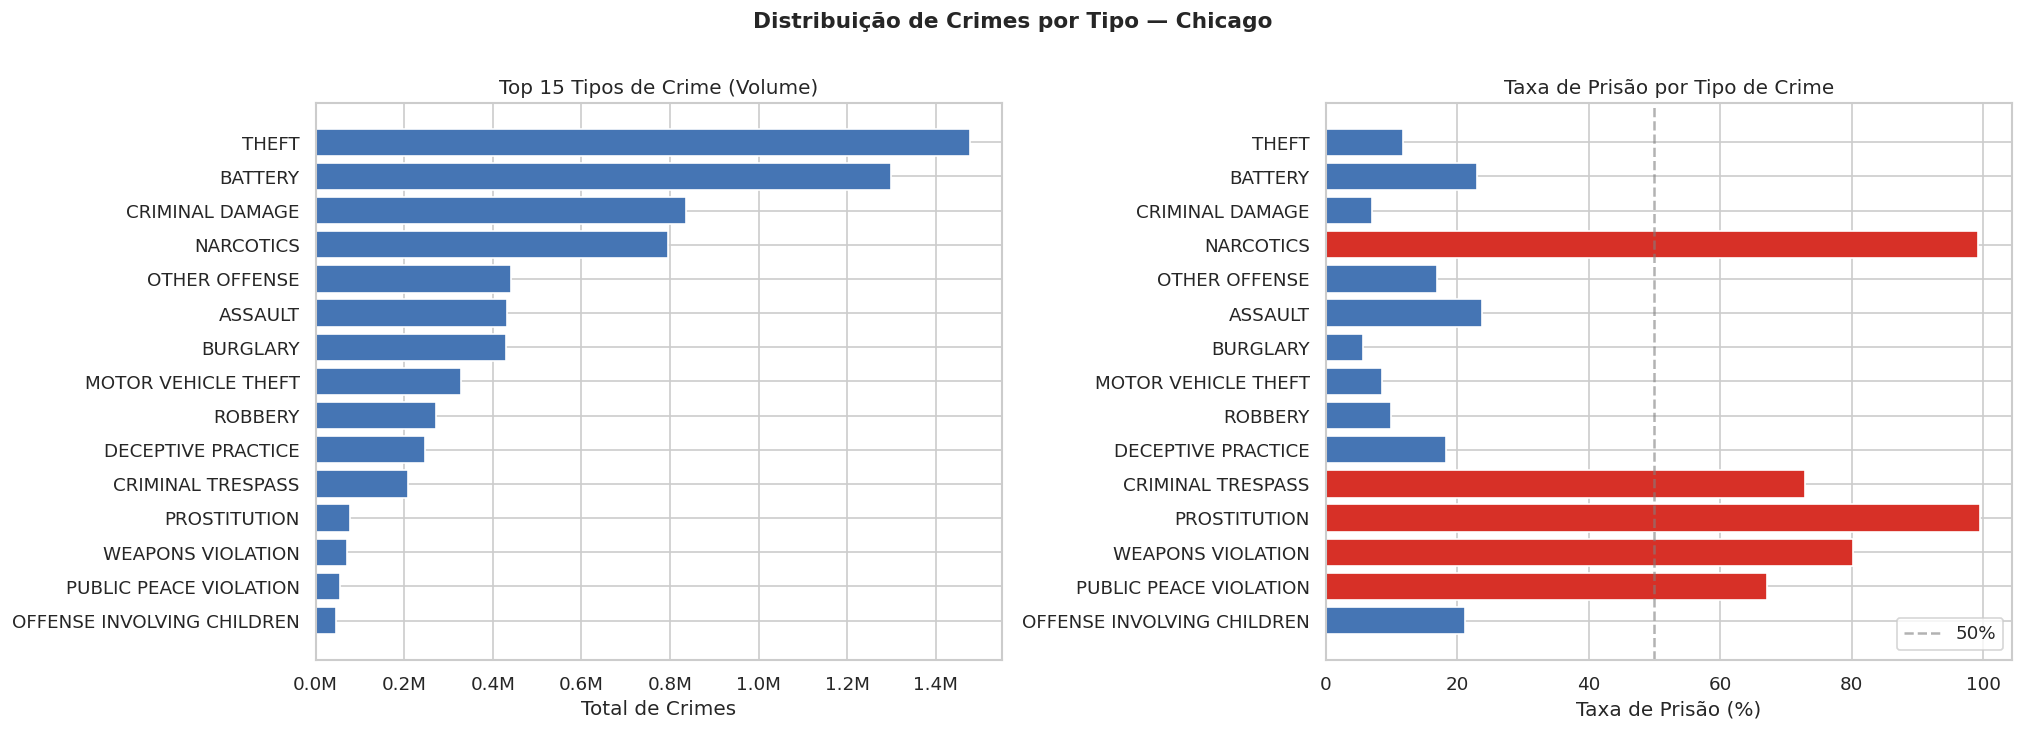

In [27]:
# --- 4.1 Distribuição de Crimes por Tipo ---
df_crimes_pd = spark.sql("""
    SELECT `Primary Type`,
           COUNT(*)                                        AS total_crimes,
           ROUND(SUM(Arrest_label) / COUNT(*) * 100, 2)  AS arrest_rate_pct
    FROM crimes
    GROUP BY `Primary Type`
    ORDER BY total_crimes DESC
    LIMIT 15
""").toPandas().iloc[::-1].reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

axes[0].barh(df_crimes_pd["Primary Type"], df_crimes_pd["total_crimes"], color="#4575b4")
axes[0].set_xlabel("Total de Crimes")
axes[0].set_title("Top 15 Tipos de Crime (Volume)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

colors = ["#d73027" if r > 50 else "#4575b4" for r in df_crimes_pd["arrest_rate_pct"]]
axes[1].barh(df_crimes_pd["Primary Type"], df_crimes_pd["arrest_rate_pct"], color=colors)
axes[1].set_xlabel("Taxa de Prisão (%)")
axes[1].set_title("Taxa de Prisão por Tipo de Crime")
axes[1].axvline(50, color="gray", linestyle="--", alpha=0.6, label="50%")
axes[1].legend(loc="lower right")

plt.suptitle("Distribuição de Crimes por Tipo — Chicago", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(SAVE_DIR + "chart_01_crime_types.png", bbox_inches="tight")
plt.show()

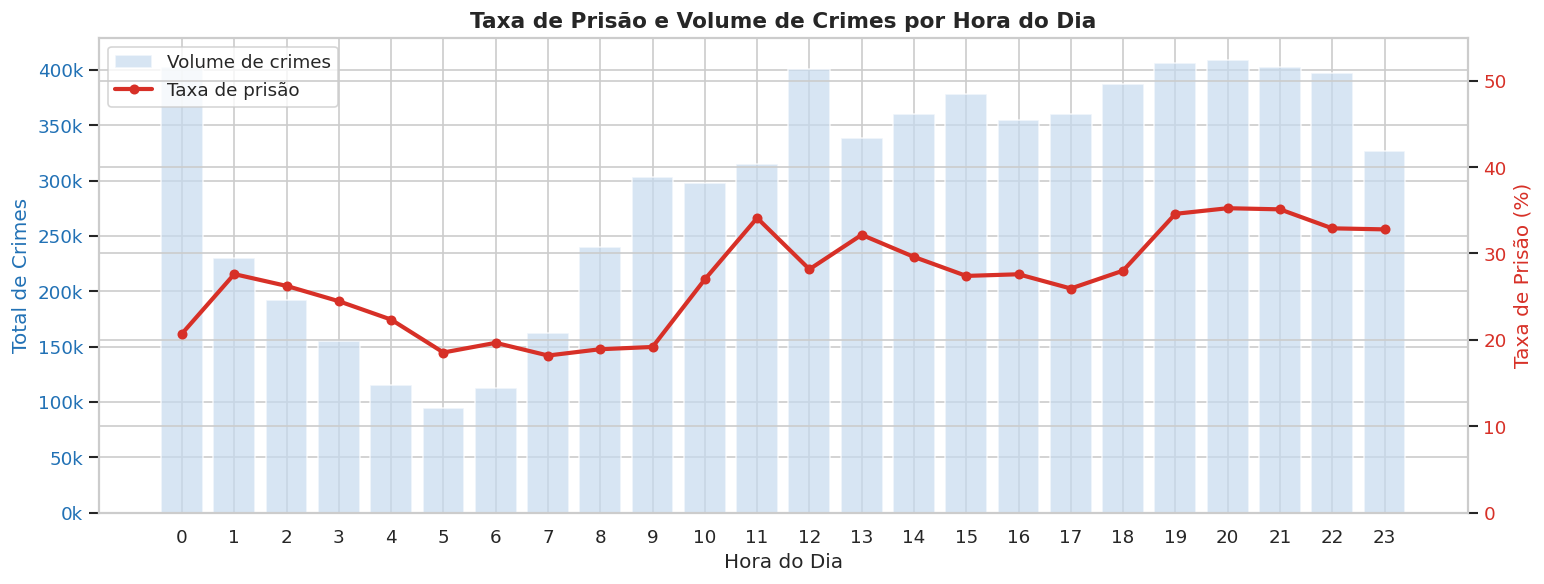

In [28]:
# --- 4.2 Taxa de Prisão por Hora do Dia ---
df_hour_pd = spark.sql("""
    SELECT Hour,
           COUNT(*)                            AS total_crimes,
           ROUND(AVG(Arrest_label) * 100, 2)  AS arrest_rate_pct
    FROM crimes
    GROUP BY Hour
    ORDER BY Hour
""").toPandas()

fig, ax1 = plt.subplots(figsize=(13, 5))

color_bar = "#c6dbef"
color_line = "#d73027"

ax1.bar(df_hour_pd["Hour"], df_hour_pd["total_crimes"], color=color_bar, alpha=0.7, label="Volume de crimes")
ax1.set_xlabel("Hora do Dia")
ax1.set_ylabel("Total de Crimes", color="#2171b5")
ax1.tick_params(axis="y", labelcolor="#2171b5")
ax1.set_xticks(range(0, 24))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))

ax2 = ax1.twinx()
ax2.plot(df_hour_pd["Hour"], df_hour_pd["arrest_rate_pct"], color=color_line,
         linewidth=2.5, marker="o", markersize=5, label="Taxa de prisão")
ax2.set_ylabel("Taxa de Prisão (%)", color=color_line)
ax2.tick_params(axis="y", labelcolor=color_line)
ax2.set_ylim(0, 55)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Taxa de Prisão e Volume de Crimes por Hora do Dia", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR + "chart_02_arrest_by_hour.png", bbox_inches="tight")
plt.show()

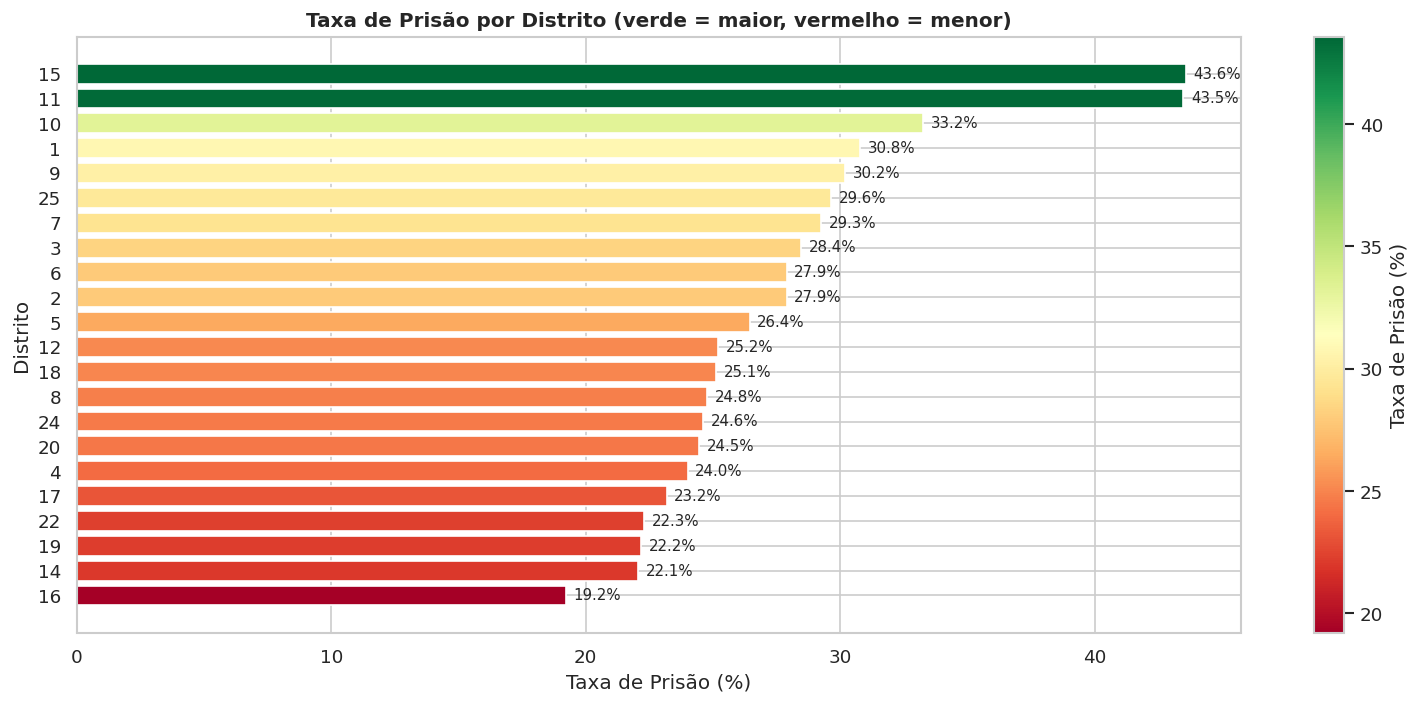

In [29]:
# --- 4.3 Taxa de Prisão por Distrito ---
df_dist_pd = spark.sql("""
    SELECT District,
           COUNT(*)                                        AS total_crimes,
           ROUND(SUM(Arrest_label) / COUNT(*) * 100, 2)  AS arrest_rate_pct
    FROM crimes
    WHERE District IS NOT NULL
    GROUP BY District
    HAVING COUNT(*) > 1000
    ORDER BY District
""").toPandas().sort_values("arrest_rate_pct")

fig, ax = plt.subplots(figsize=(13, 6))

norm = plt.Normalize(df_dist_pd["arrest_rate_pct"].min(), df_dist_pd["arrest_rate_pct"].max())
cmap = plt.cm.RdYlGn
colors = cmap(norm(df_dist_pd["arrest_rate_pct"]))

bars = ax.barh(df_dist_pd["District"].astype(str), df_dist_pd["arrest_rate_pct"], color=colors)
ax.set_xlabel("Taxa de Prisão (%)")
ax.set_ylabel("Distrito")
ax.set_title("Taxa de Prisão por Distrito (verde = maior, vermelho = menor)", fontsize=12, fontweight="bold")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Taxa de Prisão (%)")

for bar, val in zip(bars, df_dist_pd["arrest_rate_pct"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(SAVE_DIR + "chart_03_arrest_by_district.png", bbox_inches="tight")
plt.show()

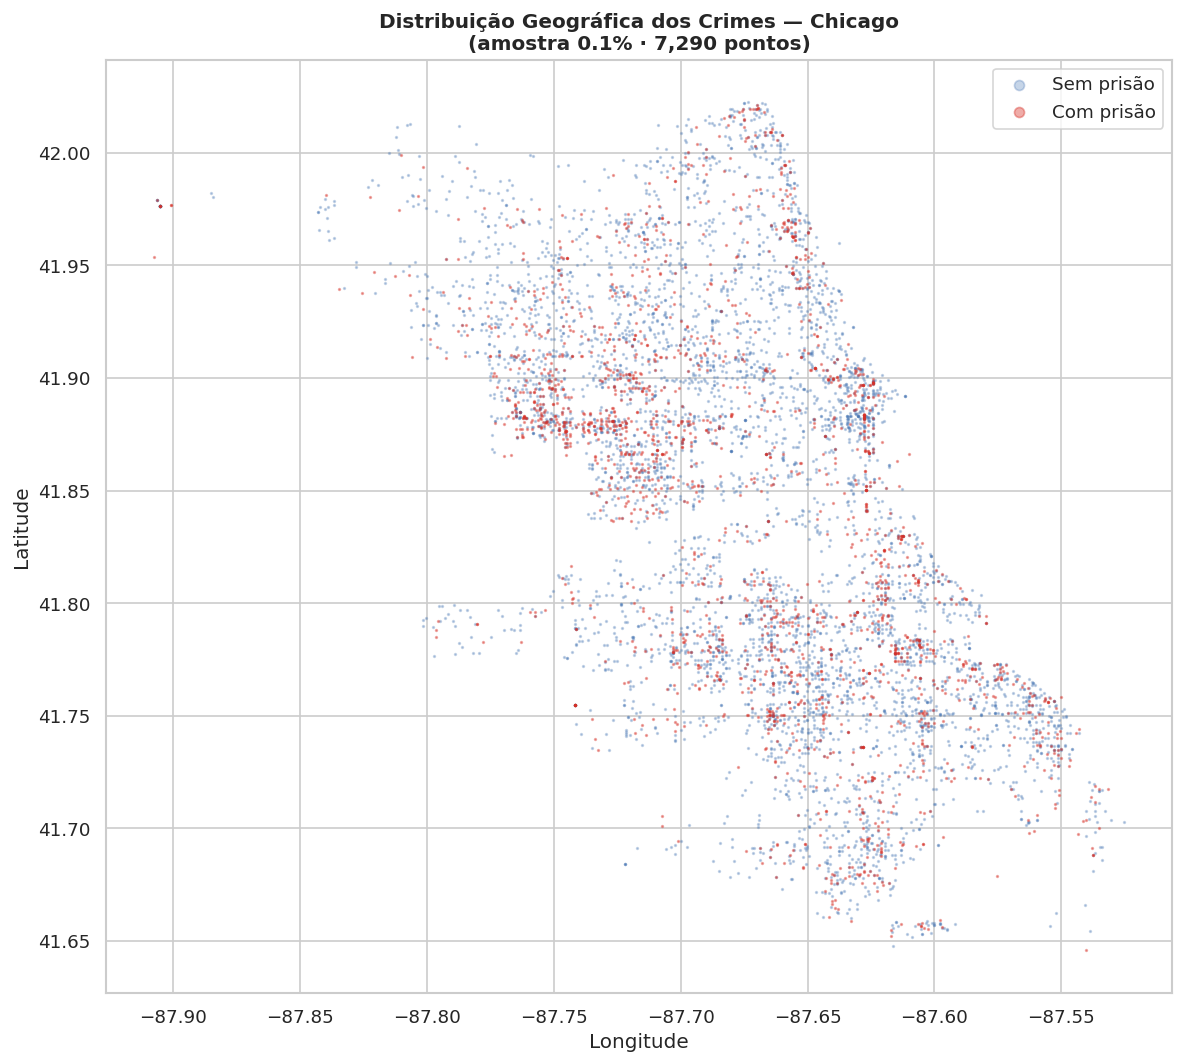

In [30]:
# --- 4.4 Distribuição Geográfica dos Crimes ---
df_geo_pd = spark.sql("""
    SELECT Latitude, Longitude, Arrest_label
    FROM crimes
    WHERE Latitude IS NOT NULL AND Longitude IS NOT NULL
""").sample(fraction=0.005, seed=42).toPandas()

arrested     = df_geo_pd[df_geo_pd["Arrest_label"] == 1]
not_arrested = df_geo_pd[df_geo_pd["Arrest_label"] == 0]
n_pts = len(df_geo_pd)

fig, axes = plt.subplots(1, 2, figsize=(17, 8))

# Painel esquerdo: densidade hexbin
hb = axes[0].hexbin(
    df_geo_pd["Longitude"], df_geo_pd["Latitude"],
    gridsize=60, cmap="YlOrRd", mincnt=1, linewidths=0.15
)
plt.colorbar(hb, ax=axes[0], label="Nº de crimes")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_title("Densidade de Crimes (Hexbin)", fontsize=12, fontweight="bold")

# Painel direito: scatter por resultado de prisão
axes[1].scatter(not_arrested["Longitude"], not_arrested["Latitude"],
                s=2, alpha=0.25, color="#4575b4", label="Sem prisão")
axes[1].scatter(arrested["Longitude"], arrested["Latitude"],
                s=2, alpha=0.35, color="#d73027", label="Com prisão")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].set_title("Resultado de Prisão por Localização", fontsize=12, fontweight="bold")
axes[1].legend(markerscale=5, loc="upper right")

plt.suptitle(
    f"Distribuição Geográfica dos Crimes — Chicago\n(amostra 0.5% · {n_pts:,} pontos)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig(SAVE_DIR + "chart_04_geographic.png", bbox_inches="tight", dpi=150)
plt.show()

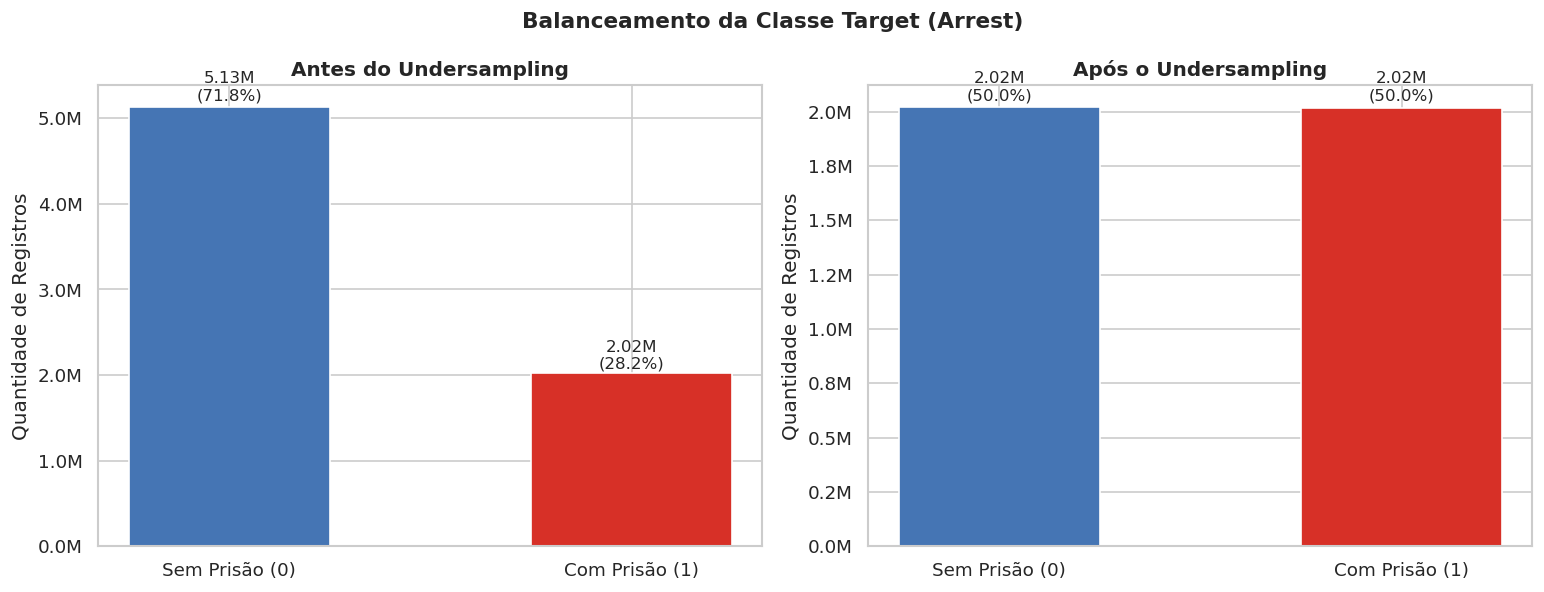

In [31]:
# --- 4.5 Desbalanceamento de Classes — Antes e Depois do Undersampling ---
# Usa os valores calculados na seção 2.5 / 2.6
labels_before = ["Sem Prisão (0)", "Com Prisão (1)"]
labels_after  = ["Sem Prisão (0)", "Com Prisão (1)"]

try:
    before_vals = [count_no_arrest, count_arrest]
    after_no    = df_balanced.filter(col(TARGET_COL) == 0).count()
    after_yes   = df_balanced.filter(col(TARGET_COL) == 1).count()
    after_vals  = [after_no, after_yes]
except NameError:
    # Fallback com valores da primeira execução (CLAUDE.md)
    before_vals = [5_127_304, 2_018_002]
    after_vals  = [2_019_328, 2_018_002]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ["#4575b4", "#d73027"]

for ax, vals, title in zip(axes,
                            [before_vals, after_vals],
                            ["Antes do Undersampling", "Após o Undersampling"]):
    bars = ax.bar(labels_before, vals, color=colors, width=0.5)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("Quantidade de Registros")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
    total = sum(vals)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                f"{v/1e6:.2f}M\n({v/total*100:.1f}%)", ha="center", va="bottom", fontsize=10)

plt.suptitle("Balanceamento da Classe Target (Arrest)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR + "chart_05_class_balance.png", bbox_inches="tight")
plt.show()

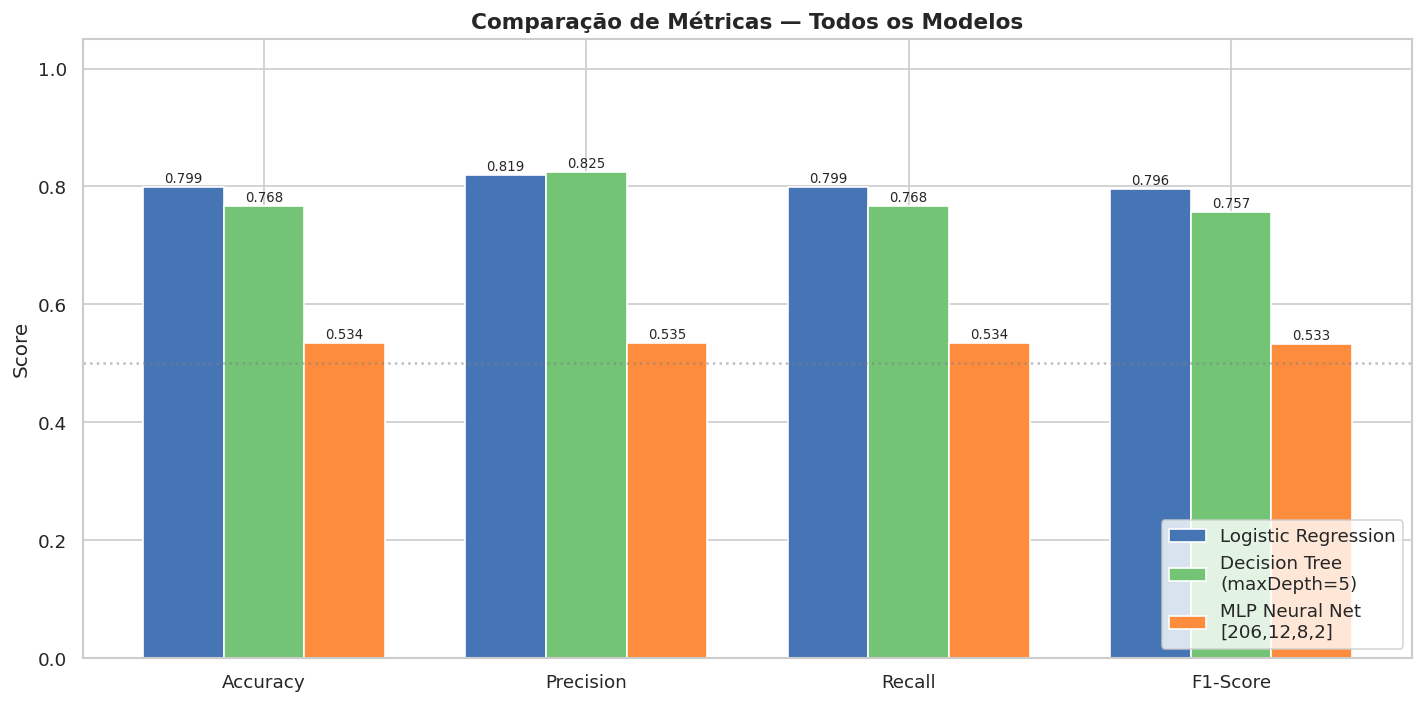

In [32]:
# --- 4.6 Comparação de Métricas dos Modelos ---
model_names  = ["Logistic Regression", "Decision Tree\n(maxDepth=5)", "MLP Neural Net\n[206,12,8,2]"]
metric_names = ["accuracy", "weightedPrecision", "weightedRecall", "f1"]
metric_labels = ["Accuracy", "Precision", "Recall", "F1-Score"]

# Coleta resultados — usa fallback da primeira execução se variáveis não existirem
def _get(d, k):
    try: return d[k]
    except: return None

try:    row_lr = [metrics_lr[k]  for k in metric_names]
except: row_lr = [0.7992, 0.8192, 0.7992, 0.7959]

try:    row_dt = [metrics_dt[k]  for k in metric_names]
except: row_dt = [0.7677, 0.8253, 0.7677, 0.7568]

try:    row_mlp = [metrics_mlp[k] for k in metric_names]
except: row_mlp = [None, None, None, None]

rows = [row_lr, row_dt, row_mlp]

x    = np.arange(len(metric_labels))
w    = 0.25
fig, ax = plt.subplots(figsize=(12, 6))

colors_models = ["#4575b4", "#74c476", "#fd8d3c"]
for i, (name, row, color) in enumerate(zip(model_names, rows, colors_models)):
    vals = [v if v is not None else 0 for v in row]
    bars = ax.bar(x + i * w, vals, w, label=name, color=color)
    for bar, v in zip(bars, row):
        if v is not None:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=8)
        else:
            ax.text(bar.get_x() + bar.get_width() / 2, 0.02,
                    "N/A", ha="center", va="bottom", fontsize=8, color="gray")

ax.set_xticks(x + w)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Comparação de Métricas — Todos os Modelos", fontsize=13, fontweight="bold")
ax.legend(loc="lower right")
ax.axhline(0.5, color="gray", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.savefig(SAVE_DIR + "chart_06_model_comparison.png", bbox_inches="tight")
plt.show()

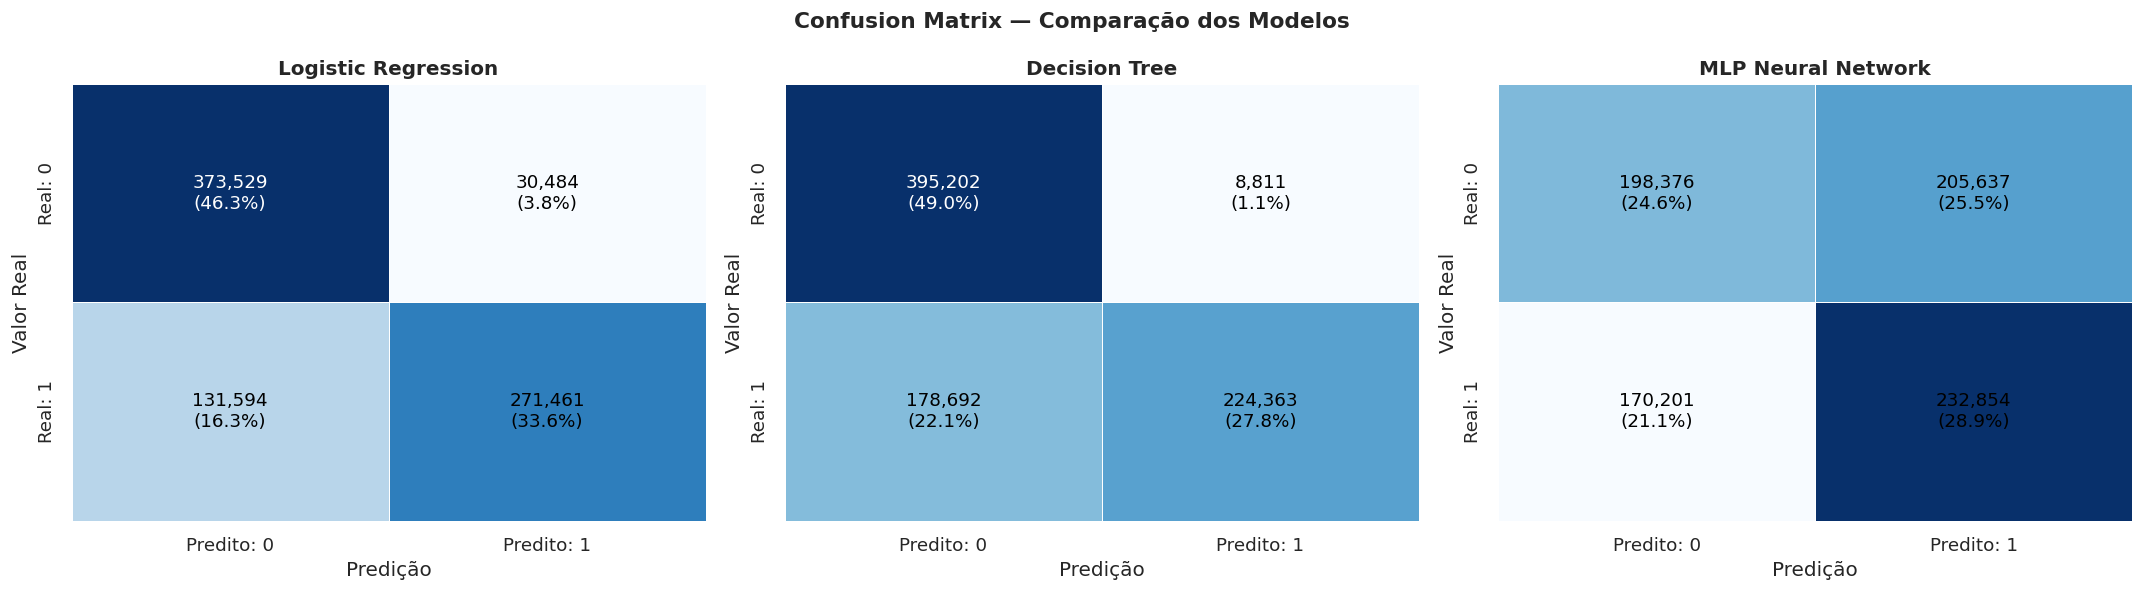

In [33]:
# --- 4.7 Confusion Matrices ---
def compute_cm(predictions):
    """Retorna matriz 2x2: linhas=Previsto, colunas=Verdadeiro (convenção padrão)."""
    cm_df = (predictions
             .groupBy(TARGET_COL, "prediction")
             .count()
             .toPandas())
    raw = np.zeros((2, 2), dtype=int)
    for _, row in cm_df.iterrows():
        real, pred = int(row[TARGET_COL]), int(row["prediction"])
        if 0 <= real <= 1 and 0 <= pred <= 1:
            raw[real][pred] = int(row["count"])
    return raw.T  # transpõe: linhas=Previsto, colunas=Real

QUAD = {(0, 0): "VN", (0, 1): "FN", (1, 0): "FP", (1, 1): "VP"}

preds_avail = []
for name, pred_var in [("Logistic Regression", "pred_lr"),
                        ("Decision Tree",       "pred_dt"),
                        ("MLP Neural Network",  "pred_mlp")]:
    try:
        preds_avail.append((name, eval(pred_var)))
    except NameError:
        print(f"  {name}: predições não disponíveis")

n = max(len(preds_avail), 1)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
if n == 1:
    axes = [axes]

for ax, (name, preds) in zip(axes, preds_avail):
    cm = compute_cm(preds)
    total = cm.sum()
    cm_pct = cm / total * 100

    sns.heatmap(cm_pct, annot=False, fmt="", cmap="Blues", ax=ax,
                xticklabels=["Verdadeiro: 0", "Verdadeiro: 1"],
                yticklabels=["Previsto: 0",   "Previsto: 1"],
                linewidths=0.5, cbar=False)

    for i in range(2):
        for j in range(2):
            label = QUAD[(i, j)]
            ax.text(j + 0.5, i + 0.35,
                    label,
                    ha="center", va="center", fontsize=13, fontweight="bold",
                    color="white" if cm_pct[i, j] > 40 else "black")
            ax.text(j + 0.5, i + 0.65,
                    f"{cm[i,j]:,}\n({cm_pct[i,j]:.1f}%)",
                    ha="center", va="center", fontsize=9,
                    color="white" if cm_pct[i, j] > 40 else "black")

    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Valor Verdadeiro")
    ax.set_ylabel("Valor Previsto")

plt.suptitle("Confusion Matrix — Comparação dos Modelos", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR + "chart_07_confusion_matrices.png", bbox_inches="tight")
plt.show()

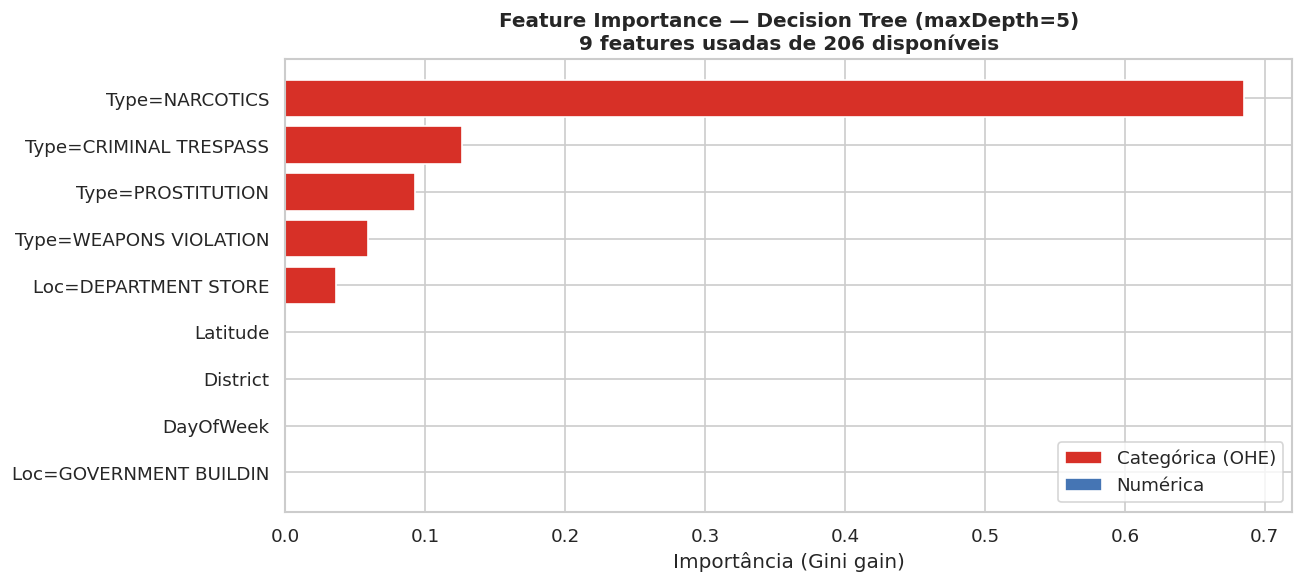

In [34]:
# --- 4.8 Feature Importance — Decision Tree ---
try:
    si_primary  = model_dt.stages[0]
    si_location = model_dt.stages[1]
    ohe         = model_dt.stages[2]
    dt_clf      = model_dt.stages[4]

    n_primary  = ohe.categorySizes[0] - 1
    n_location = ohe.categorySizes[1] - 1

    feature_names = (
        [f"Type={lbl}"      for lbl in si_primary.labels[:n_primary]]   +
        [f"Loc={lbl[:18]}"  for lbl in si_location.labels[:n_location]] +
        NUMERIC_COLS
    )

    importances = dt_clf.featureImportances.toArray()
    fi_df = (pd.DataFrame({"feature": feature_names, "importance": importances})
               .query("importance > 0")
               .sort_values("importance", ascending=False)
               .head(20)
               .iloc[::-1])

    n_features = len(fi_df)
    fig, ax = plt.subplots(figsize=(11, max(5, n_features * 0.45)))
    colors_fi = ["#d73027" if "Type=" in f or "Loc=" in f else "#4575b4"
                 for f in fi_df["feature"]]
    ax.barh(fi_df["feature"], fi_df["importance"], color=colors_fi)
    ax.set_xlabel("Importância (Gini gain)")
    # Título dinâmico: mostra quantas features realmente foram usadas pela árvore
    ax.set_title(f"Feature Importance — Decision Tree (maxDepth=5)\n{n_features} features usadas de {len(feature_names)} disponíveis",
                 fontsize=12, fontweight="bold")

    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor="#d73027", label="Categórica (OHE)"),
                       Patch(facecolor="#4575b4", label="Numérica")]
    ax.legend(handles=legend_elements, loc="lower right")

    plt.tight_layout()
    plt.savefig(SAVE_DIR + "chart_08_feature_importance.png", bbox_inches="tight")
    plt.show()

except NameError:
    print("model_dt não disponível — rode a seção 3.5 antes de executar esta célula.")

In [35]:
spark.stop()
print("SparkSession encerrada.")

SparkSession encerrada.


---
## Relatório de Conclusões

### Resultados dos Modelos (segunda execução completa)

| Modelo | Accuracy | Precision | Recall | F1-Score | Treino |
|---|---|---|---|---|---|
| Logistic Regression | **0.7992** | 0.8192 | 0.7992 | **0.7959** | 3,230,261 linhas |
| Decision Tree (maxDepth=5) | 0.7677 | **0.8253** | 0.7677 | 0.7568 | 3,230,261 linhas |
| MLP Neural Network [206,12,8,2] | — | — | — | — | ~323k linhas (10%) |

> MLP com 51% na segunda execução foi erro de implementação (pipeline refitado na amostra → encoding inconsistente). Corrigido na terceira execução usando `pre_model` do dataset completo.

### Análise dos Resultados

| Aspecto | Observação |
|---|---|
| **Melhor Accuracy e F1** | Logistic Regression (0.7992 / 0.7959) — baseline linear superou a DT |
| **Melhor Precision** | Decision Tree (0.8253) — menos falsos positivos |
| **LR vs DT** | LR venceu em accuracy e F1; DT venceu em precision. maxDepth=5 pode ser conservador demais |
| **NARCOTICS domina** | Feature importance mostra 0.69 de Gini gain — 99.21% de taxa de prisão distorce o modelo |
| **MLP na amostra** | L-BFGS não escala para 3,2M linhas com 206 features; solução: amostrar mas manter encoding do dataset completo |
| **Undersampling** | Reduziu de 7,1M → 4M linhas, equilibrando 71.8%/28.2% para 50%/50% |
| **Parquet vs CSV** | Leitura colunar reduz I/O significativamente para workloads analíticos no Spark |

### Limitações Honestas

- Árvore com maxDepth=5 é sub-ótima — vale testar maxDepth=10
- MLP treinado em apenas 10% dos dados — não comparável diretamente com LR e DT
- NARCOTICS com 99.21% de prisão cria um "atalho" que os modelos exploram — não generaliza bem para casos sem drogas
- Undersampling perde 3,1M de registros reais da classe majoritária